# LKIPA Covariance Matrix Temporal Reconstruction
---

Here we reconstruct the covariance matrix from time series data

**Notes**
1. By splitting a pixel into chunks of length $\tau$ seconds, the frequency resolution $\Delta f$ of the TL modes is given by:

$$
    \boxed{
        \Delta f = \frac{1}{\tau}
    }
$$
For a resolution of $\Delta f = 10$ kHz, we need to split the pixel into chunks of $\tau = 100 \mu$ seconds each.  

2. Use ```AdcMode.Direct``` for full 2 GHz sampling and no I/Q downconversion. 

3. From real voltage time series, perform real FFT on each chunk to obtain I/Q quadratures. 

4. Generate covariance matrix for each chunk

5. Average covariance matrices over all chunks

In [27]:
# IMPORTS
# =======
import os
import sys

import matplotlib.pyplot as plt
#%matplotlib widget
import numpy as np
from tqdm import tqdm

import importlib
import LKIPA_library as lib
importlib.reload(lib)

from mpl_toolkits.axes_grid1 import make_axes_locatable

# style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['axes.labelsize'] = 17
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 17
plt.rcParams['legend.frameon'] = False

# 1. Import quadrature data from hdf5 file

In [28]:
folder = r'/media/nanophys-meas/DR_BACKUP/Jai LKIPA Data/2026-07/Time series'   # Choose folder for current month and measurement type

file = sorted(                                                                  # Get the most recent hdf5 file in the folder 
        (f for f in os.listdir(folder) if f.endswith('.hdf5')),
        key=lambda f: os.path.getmtime(os.path.join(folder, f))
    )[-1]   

myrun = file.split('.')[0]                                                      # Get the run name from the file name

file = os.path.join(folder, file)

print(myrun)

2026-07-21_08_22_08


In [29]:
pump_idx = 0

pump_freq, pump_amp, df, f_NCO, dc_bias, N_pixels, I_arr, Q_arr, t_ns, fs = lib.retrieve_data(folder, file, myrun, pump_idx)

# 2. Complex FFT to get I/Q for each mode

### 2.1 Define central time interval $T(0)$ and 1-time lag interval $T(\tau)$

In [30]:
# Measurement time interval properties

t_us = t_ns * 1e-3         # Convert time from ns to us

dt_us = t_us[1] - t_us[0]  # Get time step in us

n_samples = len(t_us)      # Get number of samples in the time series

# interval size and delay

n_interval = 1000  # Set the number of samples in the correlation interval

n_delay = 20       # tau = n_delay * dt_us

# Central interval

T_0 = lib.get_correlation_interval(t_us, n_interval, 0)  # Get the correlation interval

I_0, Q_0 = lib.get_correlation_quadratures(I_arr, Q_arr, n_interval, 0)  # Get the correlation quadratures

# Delayed interval

T_tau = lib.get_correlation_interval(t_us, n_interval, n_delay)  # Get the correlation interval for delay

I_tau, Q_tau = lib.get_correlation_quadratures(I_arr, Q_arr, n_interval, n_delay)  # Get the correlation quadratures for delays

### 2.2 Complex FFT of center and delayed interval

In [31]:
N_pix = np.shape(I_0)[0]  # Get the number of pixels

# frequency array for FFT
f_list = np.fft.fftfreq(n_interval, dt_us)  # MHz

# Shift frequencies to be centered around zero for plotting 
f_list_ordered = np.fft.fftshift(f_list)

# Quadrature FFT arrays for the center interval 
I_fft_0 = np.zeros((N_pix, n_interval))
Q_fft_0 = np.zeros((N_pix, n_interval))

# Quadrature FFT arrays for the delayed interval 
I_fft_tau = np.zeros((N_pix, n_interval))
Q_fft_tau = np.zeros((N_pix, n_interval))

for pix in range(N_pix):

    # Define complex voltages for the pixel
    V_0 = I_0[pix] + 1j * Q_0[pix]  # Get the complex voltage for the pixel
    V_tau = I_tau[pix] + 1j * Q_tau[pix]  # Get the complex voltage for the pi

    # Get ffts for the pixel
    V_fft_0 = np.fft.fftshift(np.fft.fft(V_0))          # Center 
    V_fft_tau = np.fft.fftshift(np.fft.fft(V_tau))      # Delayed 

    # Phase shift each mode to account for propagation drift \delta \phi = 2 * pi * f_mode * tau
    #V_fft_tau *= np.exp(-1j * 2 * np.pi * f_list * n_delay * dt_us) 

    # Assign mode quadratures fft arrays
    I_fft_0[pix] = np.real(V_fft_0)
    Q_fft_0[pix] = np.imag(V_fft_0)
    I_fft_tau[pix] = np.real(V_fft_tau) 
    Q_fft_tau[pix] = np.imag(V_fft_tau)



### 2.3 Output modes for covariance matrix

In [35]:
modes = 10
mode_ids = np.arange(n_interval // 2 - modes, n_interval // 2 + modes + 1)

f_comb = f_list_ordered[mode_ids]  # Get the frequency comb for the modes

# Quadratures for center interval modes
I_modes_0 = I_fft_0[:, mode_ids]  
Q_modes_0 = Q_fft_0[:, mode_ids]  

# Quadratures for delayed interval modes
I_modes_tau = I_fft_tau[:, mode_ids]  
Q_modes_tau = Q_fft_tau[:, mode_ids] 

### 2.4 Delayed covariance matrix

In [36]:
cov_tau = lib.covariance_matrix(I_modes_0, Q_modes_0, I_modes_tau, Q_modes_tau)

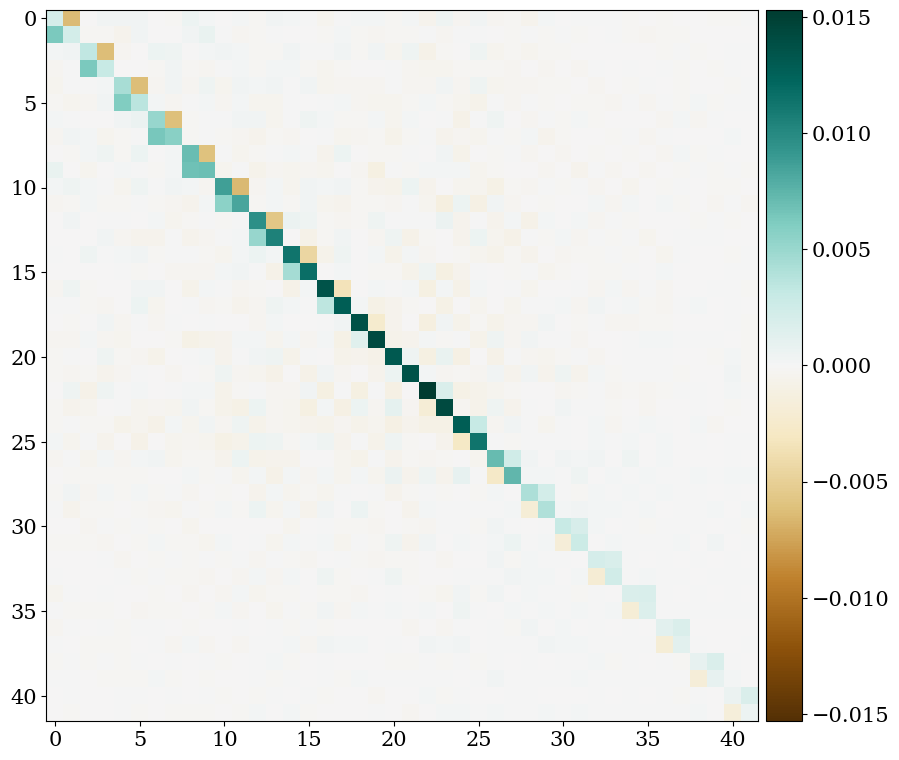

In [37]:
max_cov = np.max(cov_tau)
min_cov = -max_cov

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    cov_tau,
    aspect='equal',
    cmap='BrBG',
    origin='upper',
    vmax=max_cov,
    vmin=min_cov
)

# Colorbar exactly as tall as the matrix
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.08)
cbar = fig.colorbar(im, cax=cax)